## Imports

In [ ]:
# --- Standard library ---
import os
import sys
import joblib

sys.path.append("..")

# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- sklearn: preprocessing / pipelines ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# --- sklearn: split + metrics ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score,
    brier_score_loss
)

# --- sklearn: calibration ---
from sklearn.calibration import calibration_curve

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Project configuration ---
from config import (
    COLUMN_RENAME_MAP,
    NUMERICAL_FEATURES,
    ORDINAL_FEATURES,
    CATEGORICAL_FEATURES,
    BINARY_FEATURES
)

# --- Paths ---
DATA_PATH = "../data/raw/german_credit_data.csv"
ARTIFACT_DIR = "../artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load Data

In [11]:
df = pd.read_csv(DATA_PATH)

df = df.rename(columns=COLUMN_RENAME_MAP)
df["default"] = 1 - df["kredit"]
df = df.drop(columns=["kredit"])

X = df.drop(columns=["default"])
y = df["default"]

# Feature groups from config.py
numerical_features = NUMERICAL_FEATURES
ordinal_features = ORDINAL_FEATURES
categorical_features = CATEGORICAL_FEATURES
binary_features = BINARY_FEATURES



## Preprocessing Pipelines

LR: scaled numerics + drop-first one-hot. Trees: unscaled numerics + full one-hot.

In [12]:
def make_preprocessor(scale_numeric: bool, drop_first: bool):
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    cat_transformer = OneHotEncoder(
        handle_unknown="ignore",
        drop="first" if drop_first else None,
        sparse_output=False
    )
    return ColumnTransformer(
        transformers=[
            ("num", num_transformer, numerical_features),
            ("cat", cat_transformer, categorical_features),
            ("ord", "passthrough", ordinal_features),
            ("bin", "passthrough", binary_features),
        ],
        remainder="drop"
    )

preprocess_lr = make_preprocessor(scale_numeric=True, drop_first=True)
preprocess_tree = make_preprocessor(scale_numeric=False, drop_first=False)


## Define Model Pipelines
- Logistic Regression
- Random Forest
- XGBoost

In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess_lr),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocess_tree),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("preprocess", preprocess_tree),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}


## Baseline Ranking Metrics

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

baseline_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    baseline_rows.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("ROC-AUC", ascending=False)
print("\n=== Baseline ranking metrics ===")
print(baseline_df.to_string(index=False))



=== Baseline ranking metrics ===
              Model  ROC-AUC   PR-AUC
      Random Forest 0.777219 0.657006
            XGBoost 0.775314 0.644512
Logistic Regression 0.755810 0.602837


#### Results

- **Random Forest** achieves the highest ROC-AUC.
- **XGBoost** performs very similarly.
- **Logistic Regression** performs clearly weaker in pure discrimination.

### Interpretation

From a **ranking perspective**, tree-based ensemble models outperform Logistic Regression.  
They better separate defaulters from non-defaulters across the entire probability range.

However, ranking quality alone does not determine optimal decision-making once thresholds and asymmetric costs are introduced.

This motivates evaluating models under explicit decision rules.


## Thresholding

### Recall-constrained thresholding

In [15]:
# Helper: relative cost function (weighted error count)
def relative_cost(fp: int, fn: int, ratio: int, fp_cost: float = 1.0) -> float:
    return ratio * fn * fp_cost + fp * fp_cost


In [16]:
def eval_at_recall_targets(fitted_model, X_test, y_test, recall_targets, n_grid=2001):
    proba = fitted_model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0, 1, n_grid)
    rows = []

    for target in recall_targets:
        best = None
        for t in thresholds:
            y_hat = (proba >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

            rec = recall_score(y_test, y_hat, zero_division=0)
            diff = abs(rec - target)

            if (best is None) or (diff < best["diff"]) or (diff == best["diff"] and t > best["Threshold"]):
                best = {
                    "Target recall": float(target),
                    "Threshold": float(t),
                    "Recall": float(rec),
                    "Precision": float(precision_score(y_test, y_hat, zero_division=0)),
                    "F1": float(f1_score(y_test, y_hat, zero_division=0)),
                    "TP": int(tp),
                    "FP": int(fp),
                    "FN": int(fn),
                    "TN": int(tn),
                    "diff": float(diff),
                }
        rows.append(best)

    return pd.DataFrame(rows).drop(columns=["diff"])


def add_cost_columns(df, ratios=(5, 10), fp_cost=1.0):
    out = df.copy()
    for r in ratios:
        out[f"Cost_{r}to1"] = out.apply(lambda row: relative_cost(row["FP"], row["FN"], r, fp_cost), axis=1)
    return out


recall_targets = (0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95)

rows = []
for name, model in models.items():
    tmp = eval_at_recall_targets(model, X_test, y_test, recall_targets=recall_targets)
    tmp.insert(0, "Model", name)
    rows.append(tmp)

threshold_results = pd.concat(rows, ignore_index=True)
threshold_results_cost = add_cost_columns(threshold_results, ratios=(5, 10))

disp_recall = threshold_results_cost.copy()
disp_recall["Target recall"] = (disp_recall["Target recall"] * 100).round(0).astype(int).astype(str) + "%"
disp_recall["Recall"] = (disp_recall["Recall"] * 100).round(1)
disp_recall["Precision"] = (disp_recall["Precision"] * 100).round(1)
disp_recall["F1"] = (disp_recall["F1"] * 100).round(1)
disp_recall["Threshold"] = disp_recall["Threshold"].round(3)
disp_recall["Cost_5to1"] = disp_recall["Cost_5to1"].round(0).astype(int)
disp_recall["Cost_10to1"] = disp_recall["Cost_10to1"].round(0).astype(int)

print("\n=== Recall-target thresholding + costs ===")
print(disp_recall.sort_values(["Target recall", "Model"]).to_string(index=False))



=== Recall-target thresholding + costs ===
              Model Target recall  Threshold  Recall  Precision   F1  TP  FP  FN  TN  Cost_5to1  Cost_10to1
Logistic Regression           65%      0.332    65.3       51.6 57.6  49  46  26 129        176         306
      Random Forest           65%      0.356    65.3       50.5 57.0  49  48  26 127        178         308
            XGBoost           65%      0.285    65.3       50.0 56.6  49  49  26 126        179         309
Logistic Regression           70%      0.283    69.3       46.8 55.9  52  59  23 116        174         289
      Random Forest           70%      0.312    69.3       47.3 56.2  52  58  23 117        173         288
            XGBoost           70%      0.270    69.3       49.5 57.8  52  53  23 122        168         283
Logistic Regression           75%      0.239    74.7       45.5 56.6  56  67  19 108        162         257
      Random Forest           75%      0.284    74.7       45.5 56.6  56  67  19 108        

In this setup, we fix minimum recall levels (65%–95%) and compare models at identical operating points.

#### Key Observations

- At moderate recall levels (70–85%), **XGBoost generally achieves the best F1 and lowest cost**.
- Increasing recall reduces FN but increases FP.
- Under both 5:1 and 10:1 cost ratios, higher recall tends to reduce weighted cost within the tested range.

#### Interpretation

Under institutional constraints such as:

> "We must detect at least 70–80% of defaulters."

Tree ensembles, particularly XGBoost, provide the most favorable trade-off between false positives and false negatives.

This represents a **risk appetite / regulatory driven perspective**, where minimum detection requirements dominate decision-making.


### Cost-optimal thresholding

In [17]:
def cost_curve_for_model(fitted_model, X_test, y_test, fn_fp_ratio: int, n_grid=2001, fp_cost=1.0):
    proba = fitted_model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0, 1, n_grid)

    rows = []
    for t in thresholds:
        y_hat = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

        rows.append({
            "FN:FP ratio": f"{fn_fp_ratio}:1",
            "Threshold": float(t),
            "Cost": float(relative_cost(fp, fn, fn_fp_ratio, fp_cost)),
            "Recall": float(recall_score(y_test, y_hat, zero_division=0)),
            "Precision": float(precision_score(y_test, y_hat, zero_division=0)),
            "F1": float(f1_score(y_test, y_hat, zero_division=0)),
            "Pred_Default_Rate": float(y_hat.mean()),
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        })

    return pd.DataFrame(rows)


def find_cost_optimal_threshold_final(fitted_model, X_test, y_test, fn_fp_ratios=(5, 10), n_grid=2001, fp_cost=1.0):
    opt_rows = []
    curves = {}

    for r in fn_fp_ratios:
        curve = cost_curve_for_model(fitted_model, X_test, y_test, fn_fp_ratio=r, n_grid=n_grid, fp_cost=fp_cost)

        min_cost = curve["Cost"].min()
        candidates = curve[curve["Cost"] == min_cost].copy()

        # tie-break by precision, then threshold
        best = candidates.sort_values(["Precision", "Threshold"], ascending=[False, False]).iloc[0]
        opt_rows.append(best.to_dict())
        curves[f"{r}:1"] = curve

    return pd.DataFrame(opt_rows), curves


fn_fp_ratios = (5, 10)
all_opt, all_curves = [], {}

for name, model in models.items():
    opt_df, curves = find_cost_optimal_threshold_final(model, X_test, y_test, fn_fp_ratios=fn_fp_ratios)
    opt_df.insert(0, "Model", name)
    all_opt.append(opt_df)
    all_curves[name] = curves

cost_opt_final = pd.concat(all_opt, ignore_index=True)

disp_cost = cost_opt_final.copy()
disp_cost["Threshold"] = disp_cost["Threshold"].round(3)
disp_cost["Recall"] = (disp_cost["Recall"] * 100).round(1)
disp_cost["Precision"] = (disp_cost["Precision"] * 100).round(1)
disp_cost["F1"] = (disp_cost["F1"] * 100).round(1)
disp_cost["Pred_Default_Rate"] = (disp_cost["Pred_Default_Rate"] * 100).round(1)
disp_cost["Cost"] = disp_cost["Cost"].round(0).astype(int)

print("\n=== Cost-optimal thresholds + predicted default rate ===")
print(disp_cost.sort_values(["FN:FP ratio", "Cost", "Model"]).to_string(index=False))



=== Cost-optimal thresholds + predicted default rate ===
              Model FN:FP ratio  Threshold  Cost  Recall  Precision   F1  Pred_Default_Rate  TP  FP  FN  TN
Logistic Regression        10:1      0.088   142    97.3       37.4 54.1               78.0  73 122   2  53
            XGBoost        10:1      0.026   150    97.3       36.0 52.5               81.2  73 130   2  45
      Random Forest        10:1      0.150   152    96.0       37.1 53.5               77.6  72 122   3  53
Logistic Regression         5:1      0.088   132    97.3       37.4 54.1               78.0  73 122   2  53
      Random Forest         5:1      0.204   133    92.0       40.1 55.9               68.8  69 103   6  72
            XGBoost         5:1      0.072   139    89.3       40.4 55.6               66.4  67  99   8  76


## Cost-Optimal Thresholding (Economic View)

Here, recall constraints are removed and thresholds are chosen to directly minimize:

Cost = r · FN + FP

where r ∈ {5, 10} represents the relative severity of missing a defaulter.

#### Results

- Under both 5:1 and 10:1 ratios, **Logistic Regression achieves the lowest cost**.
- The cost-optimal solution pushes recall to very high levels (~97%).
- Predicted default rates become very large (≈ 78–81%).

#### Interpretation

When false negatives are heavily penalized, the economically optimal strategy becomes highly conservative.

Interestingly, the model with the weakest ranking performance (Logistic Regression) becomes optimal under strong loss asymmetry.

This demonstrates that **model superiority depends critically on the objective function.**


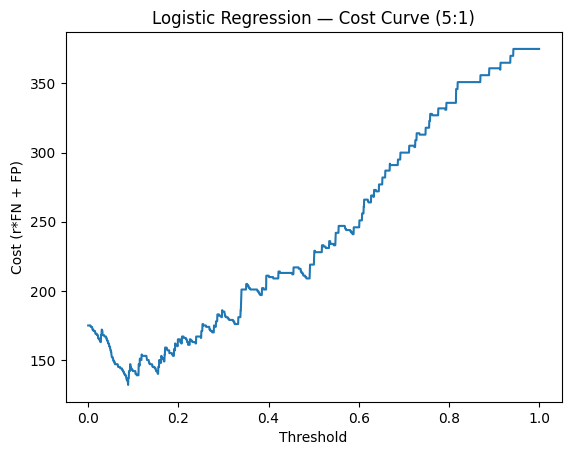

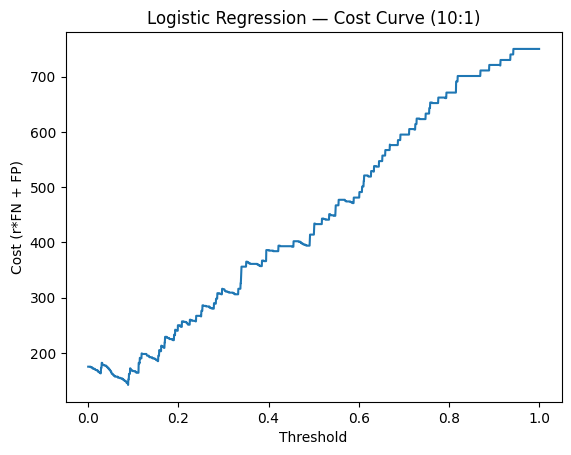

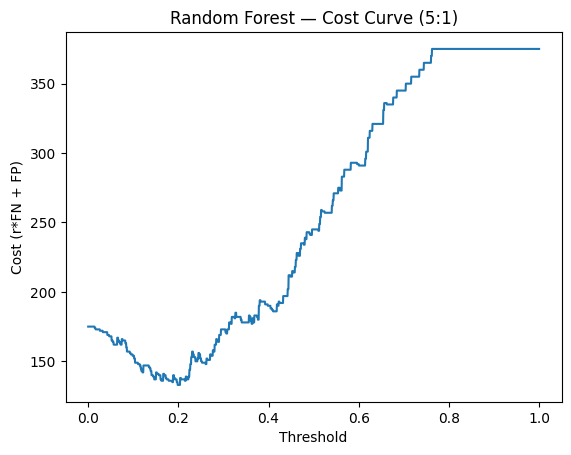

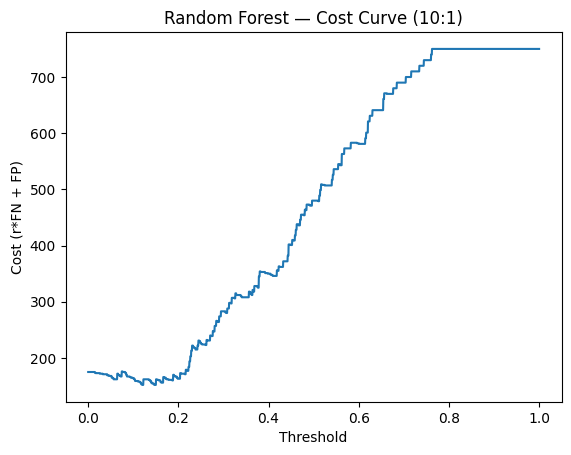

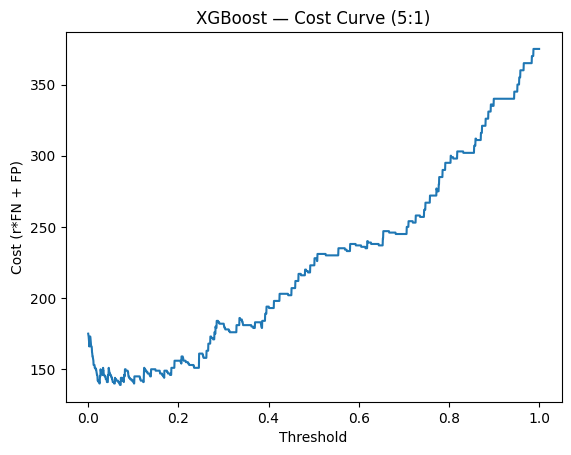

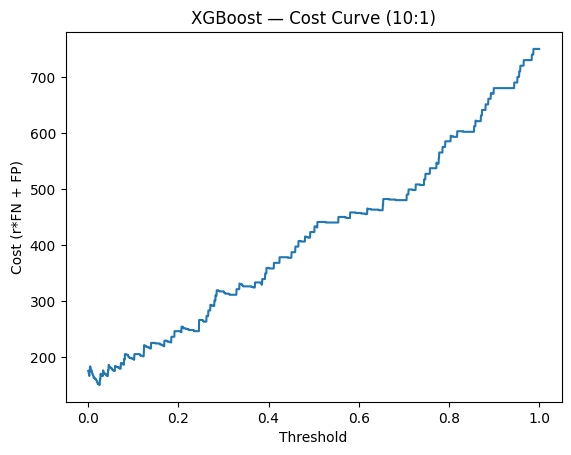

In [18]:
def plot_cost_curve(curve_df, title):
    plt.figure()
    plt.plot(curve_df["Threshold"], curve_df["Cost"])
    plt.xlabel("Threshold")
    plt.ylabel("Cost (r*FN + FP)")
    plt.title(title)
    plt.show()

for model_name, ratio_dict in all_curves.items():
    for ratio_str, curve_df in ratio_dict.items():
        plot_cost_curve(curve_df, title=f"{model_name} — Cost Curve ({ratio_str})")


#### Synthesis: Model Superiority Depends on the Objective

The results reveal three distinct realities:

| Objective | Best Model |
|------------|------------|
| Pure ranking (ROC-AUC) | Random Forest |
| Fixed recall (70–85%) | XGBoost |
| Pure cost minimization (5:1, 10:1) | Logistic Regression |

#### Interpretation

There is **no universally best model**.

Model superiority depends fundamentally on:

- The institutional objective  
- The imposed decision constraint (e.g., minimum recall)  
- The assumed loss asymmetry between false negatives and false positives  

A model that dominates in ranking performance does not necessarily minimize economic loss.  
Likewise, a model that minimizes cost under strong loss aversion may not provide the strongest discrimination.

This highlights a central insight of quantitative credit-risk modeling:

> Model evaluation must be aligned with the institutional objective and loss structure.

This is a mature and realistic perspective on credit-risk model selection.


## Calibration

Ranking and threshold analysis evaluate model decisions, but credit-risk frameworks (Basel, IFRS 9) also require that predicted PDs reflect true default probabilities. Tree ensembles are often poorly calibrated; logistic regression typically less so.

### Brier Score

Mean squared error between predicted PDs and observed outcomes. Lower is better; a naive constant base-rate predictor scores ≈ 0.21.

In [ ]:
brier_rows = []
base_rate = y_test.mean()

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, proba)

    brier_rows.append({
        "Model": name,
        "Brier": brier,
        "Mean predicted PD": proba.mean(),
        "Observed default rate": base_rate
    })

brier_df = pd.DataFrame(brier_rows).sort_values("Brier")
print("\n=== Brier score comparison (lower is better) ===")
print(brier_df.to_string(index=False))

### Brier Score (Global Probability Accuracy)

The Brier scores are very similar across models:

- Random Forest: 0.1649  
- XGBoost: 0.1712  
- Logistic Regression: 0.1745  

All models clearly outperform a naive baseline (constant base-rate predictor ≈ 0.21).  
Differences between models are modest, suggesting no severe global miscalibration.

Portfolio-level averages also align closely with the observed default rate (~30%), indicating no systematic aggregate bias.

---

### Calibration Curves

Predicted probabilities are binned; each bin's mean predicted PD is plotted against its observed default rate. Deviation from the 45° diagonal indicates miscalibration.

In [ ]:
def plot_calibration_curves(models, X_test, y_test, n_bins=10, strategy="uniform"):
    plt.figure()
    for name, model in models.items():
        proba = model.predict_proba(X_test)[:, 1]
        frac_pos, mean_pred = calibration_curve(
            y_test, proba, n_bins=n_bins, strategy=strategy
        )
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
    plt.xlabel("Mean predicted PD")
    plt.ylabel("Observed default rate")
    plt.title(f"Calibration Curves (n_bins={n_bins}, strategy={strategy})")
    plt.legend()
    plt.show()

plot_calibration_curves(models, X_test, y_test, n_bins=10, strategy="uniform")

### Calibration Curves – Local Reliability

Calibration curves reveal moderate differences in local probability reliability:

- **Logistic Regression** follows the diagonal most smoothly.
- **Random Forest** shows instability in high-probability bins.
- **XGBoost** exhibits more pronounced deviations in mid-to-high PD regions.

However, no model displays extreme systematic over- or underestimation.

The deviations are structural rather than catastrophic, and remain within a reasonable range for this dataset.

---

### Expected and Maximum Calibration Error

ECE: weighted average deviation between predicted PD and observed default rate across bins. MCE: worst-case deviation in any single bin. Both uniform and quantile binning are reported.

In [21]:
def calibration_errors(y_true, y_prob, n_bins=10, strategy="uniform"):
    """
    Returns:
      ECE: expected calibration error (weighted average gap)
      MCE: maximum calibration error (worst-bin gap)
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if strategy == "uniform":
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    elif strategy == "quantile":
        bin_edges = np.quantile(y_prob, np.linspace(0.0, 1.0, n_bins + 1))
        bin_edges[0], bin_edges[-1] = 0.0, 1.0
        bin_edges = np.unique(bin_edges)  # avoid duplicate edges if many identical probs
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    bin_ids = np.digitize(y_prob, bin_edges, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, len(bin_edges) - 2)

    ece = 0.0
    mce = 0.0
    n = len(y_true)

    for b in range(len(bin_edges) - 1):
        idx = bin_ids == b
        if idx.sum() == 0:
            continue

        bin_acc = y_true[idx].mean()      # observed default rate in bin
        bin_conf = y_prob[idx].mean()     # mean predicted PD in bin
        gap = abs(bin_acc - bin_conf)

        weight = idx.sum() / n
        ece += weight * gap
        mce = max(mce, gap)

    return ece, mce


# Compute for all models
ece_rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    ece_u, mce_u = calibration_errors(y_test, proba, n_bins=10, strategy="uniform")
    ece_q, mce_q = calibration_errors(y_test, proba, n_bins=10, strategy="quantile")
    ece_rows.append({
        "Model": name,
        "ECE (uniform, 10 bins)": ece_u,
        "MCE (uniform, 10 bins)": mce_u,
        "ECE (quantile, 10 bins)": ece_q,
        "MCE (quantile, 10 bins)": mce_q,
        "Mean predicted PD": proba.mean(),
    })

ece_df = pd.DataFrame(ece_rows).sort_values("ECE (quantile, 10 bins)")
print("\n=== Calibration errors (lower is better) ===")
print(ece_df.to_string(index=False))



=== Calibration errors (lower is better) ===
              Model  ECE (uniform, 10 bins)  MCE (uniform, 10 bins)  ECE (quantile, 10 bins)  MCE (quantile, 10 bins)  Mean predicted PD
Logistic Regression                0.069110                0.209307                 0.063309                 0.178908           0.304768
      Random Forest                0.063144                0.274167                 0.066408                 0.225000           0.306184
            XGBoost                0.100072                0.338756                 0.095037                 0.208638           0.288248


### ECE / MCE – Quantitative Calibration Errors

Expected Calibration Error (ECE) confirms:

- Logistic Regression: lowest ECE (~0.063)
- Random Forest: very similar (~0.066)
- XGBoost: moderately higher (~0.095)

Maximum Calibration Error (MCE) shows some local instability in tree-based models, but no extreme distortion.

Overall, calibration differences are present but limited in magnitude.

---

## Calibration Conclusion

Calibration analysis shows no severe probability distortion across models.

While Logistic Regression exhibits slightly more stable probability estimates and tree-based models display moderate local deviations, global calibration metrics (Brier, ECE) indicate acceptable probability reliability.

Unlike prior literature where calibration failure resulted in substantial portfolio bias, no critical under- or overpricing pattern is observed in this dataset.

Given the modest calibration differences and the absence of severe miscalibration, additional recalibration (e.g., Platt scaling or isotonic regression) is not necessary in this setting.

Model differences observed in ranking and cost-based evaluation are therefore primarily driven by discrimination characteristics rather than fundamental probability scale distortions.


## Save Models

In [22]:
import joblib

for name, model in models.items():
    joblib.dump(model, f"../artifacts/{name.replace(' ', '_')}.joblib")

In [23]:
baseline_df.to_csv("../artifacts/baseline_metrics.csv", index=False)
threshold_results_cost.to_csv("../artifacts/threshold_results.csv", index=False)
cost_opt_final.to_csv("../artifacts/cost_opt_results.csv", index=False)
ece_df.to_csv("../artifacts/calibration_metrics.csv", index=False)
